# Einleitung

Multiple Lineare Regression für die Algorithmen

In Teil 1 wird das Model für jeden Algorithmus seperat trainiert

In Teil 2 wird das Model für alle Algorithmen trainiert



# Datenvorbereitung

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Hier werden nur die Ergebnisse für das Diabetes Experiemnt geladen
random_forest_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_RandomForest.csv'
xgb_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_XGB.csv'
logistic_regression_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_LogisticRegression.csv'
knn_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_KNN.csv'
gaussian_nb_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_GaussianNB.csv'
decision_tree_data = '/content/drive/MyDrive/results/emissions_full_Diabetes_DecisionTree.csv'

In [ ]:
import pandas as pd

random_forest_df = pd.read_csv(random_forest_data)
xgb_df = pd.read_csv(xgb_data)
logistic_regression_df = pd.read_csv(logistic_regression_data)
knn_df = pd.read_csv(knn_data)
gaussian_nb_df = pd.read_csv(gaussian_nb_data)
decision_tree_df = pd.read_csv(decision_tree_data)

In [ ]:
# Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch'
}

In [ ]:
# Mappen der Features auf die Daten
dataframes = [random_forest_df, xgb_df, logistic_regression_df, knn_df, gaussian_nb_df, decision_tree_df]

for df in dataframes:
  df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
  df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jedes DataFrame in der Liste
for df in dataframes:
    df['feature_names'] = df['feature_names'].str.split(', ')
    for index, row in df.iterrows():
        features = row['feature_names']
        if isinstance(features, list):
            for feature in features:
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1

In [ ]:
# Hinzufügen von dem verwendeten Model
model_names = {
    'random_forest_df': "RandomForest",
    'xgb_df': "XGB",
    'logistic_regression_df': "LogisticRegression",
    'knn_df': "KNN",
    'gaussian_nb_df': "GaussianNB",
    'decision_tree_df': "DecisionTree"
}

for df_name, model_name in model_names.items():
    df = locals()[df_name]
    df.insert(0, 'model', model_name)

In [ ]:
# Reduzieren der Eingabeparams für das Modell und Analyse
selected_columns = ['model', 'duration', 'emissions', 'emissions_rate', 'cpu_energy', 'ram_energy', 'energy_consumed', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']

# löschen der anderen splaten
for df_name, model_name in model_names.items():
    df = locals()[df_name]

    columns_to_drop = [col for col in df.columns if col not in selected_columns]
    df.drop(columns=columns_to_drop, inplace=True)

# Datenanalyse

In [ ]:
# Funktion, die die jeweiligen Diagramme erstellt
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_correlation_matrix(df):
    # Korrelationsmatrix
    correlation_matrix = df.corr()

    # Heatmap der Korrelationsmatrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Korrelationsmatrix')
    plt.show()

## Datenvisialisierung pro Model

### Random Forest

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


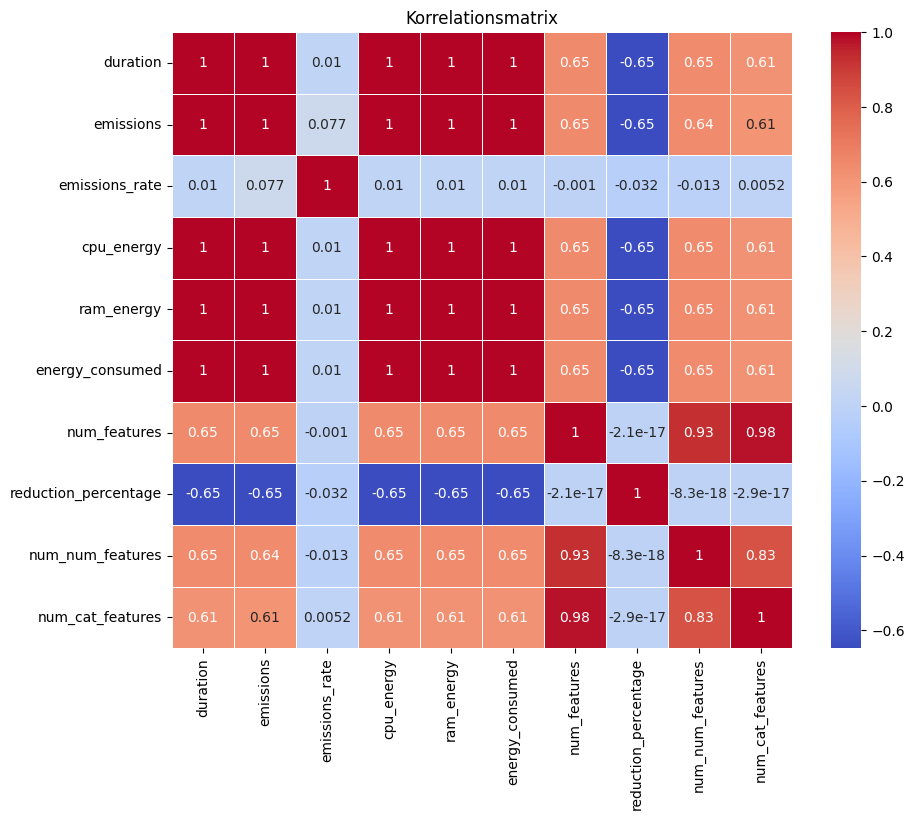

In [ ]:
visualize_correlation_matrix(random_forest_df)

### XGB

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


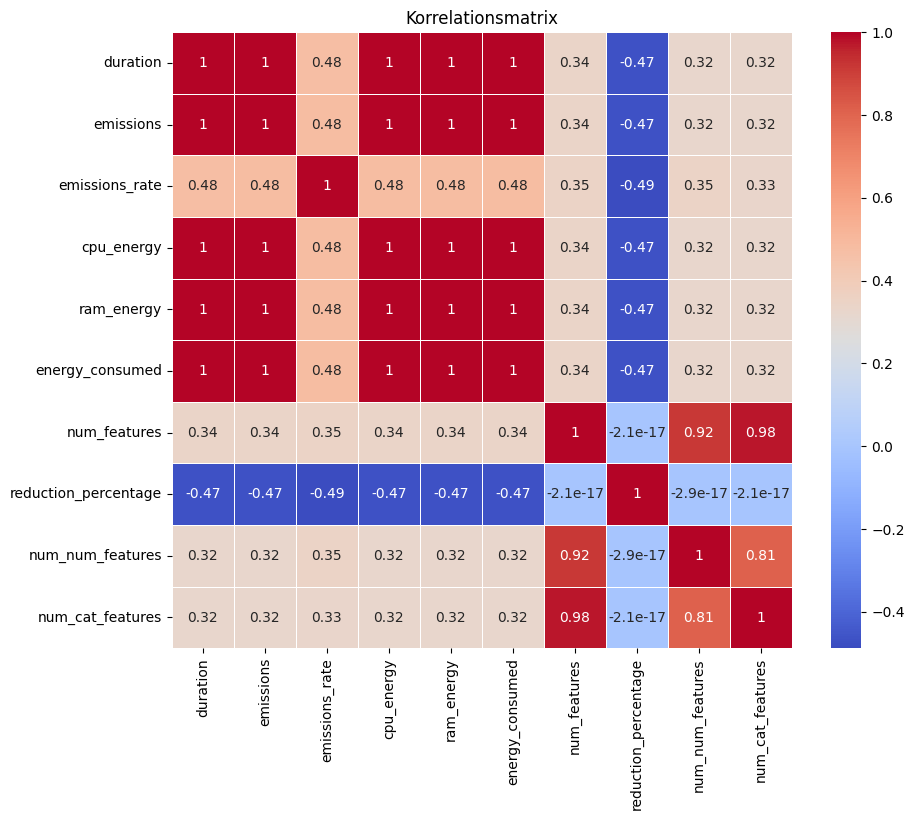

In [ ]:
visualize_correlation_matrix(xgb_df)

### Logistic Regression

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


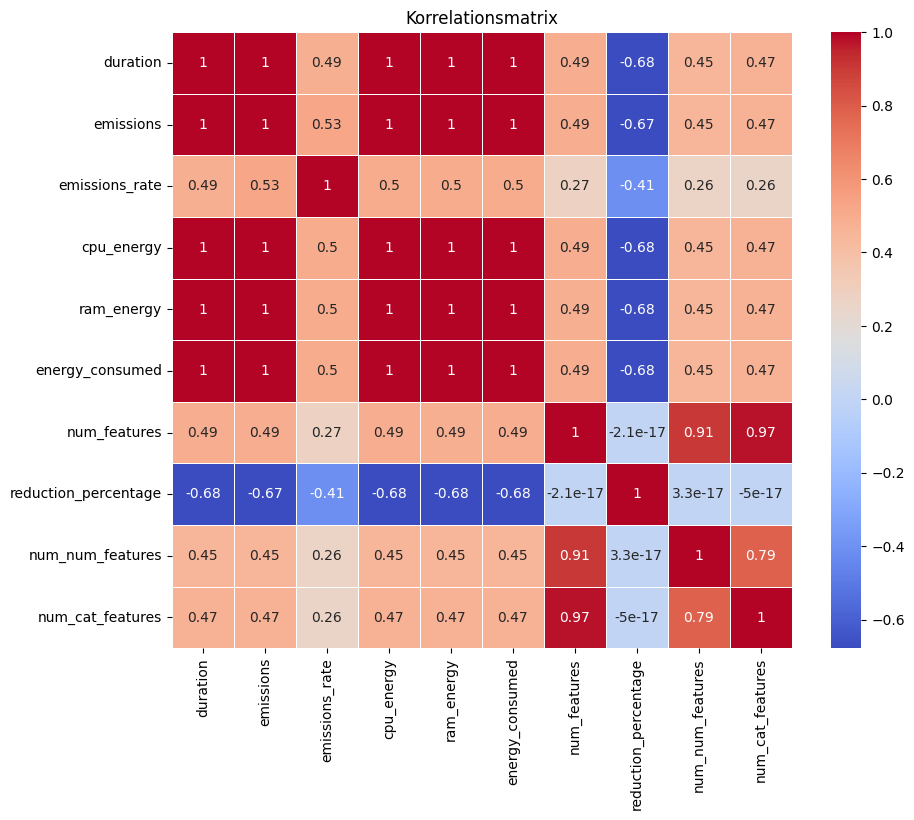

In [ ]:
visualize_correlation_matrix(logistic_regression_df)

### KNN

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


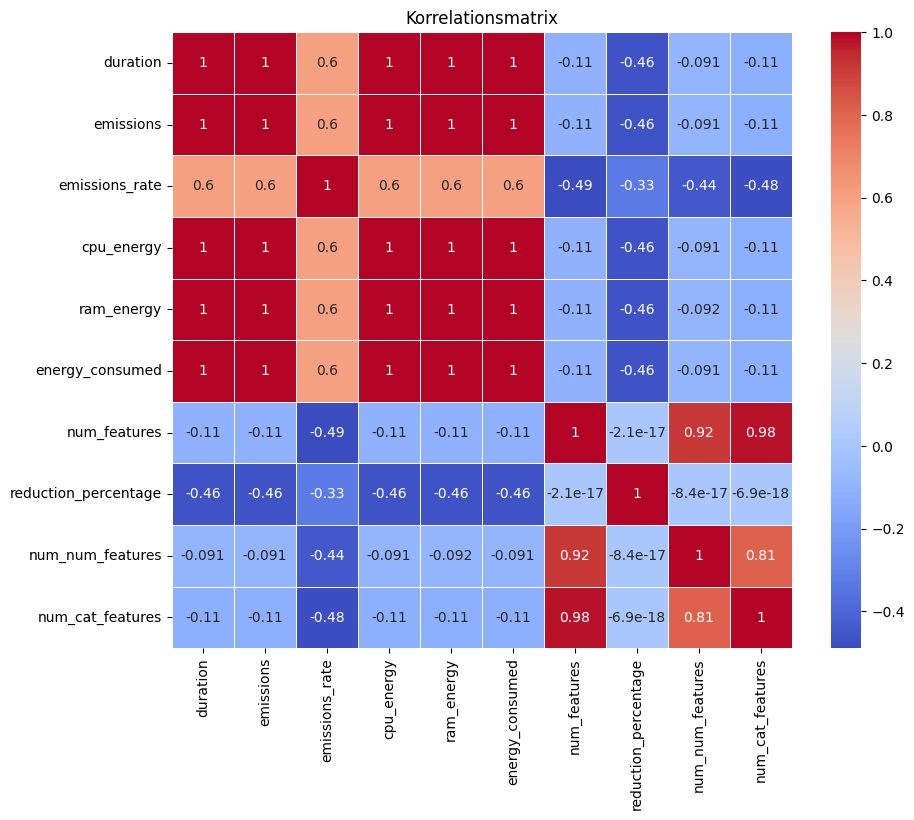

In [ ]:
visualize_correlation_matrix(knn_df)

### Gaussian

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


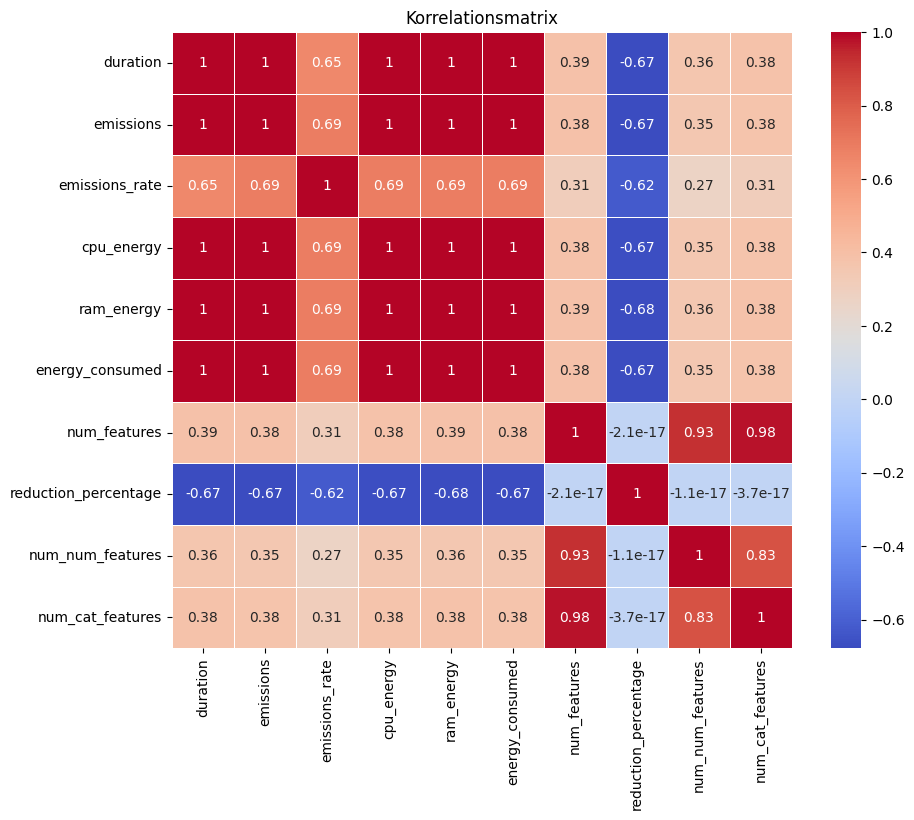

In [ ]:
visualize_correlation_matrix(gaussian_nb_df)

### Decision Tree

<ipython-input-8-33bdc76b87ed>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


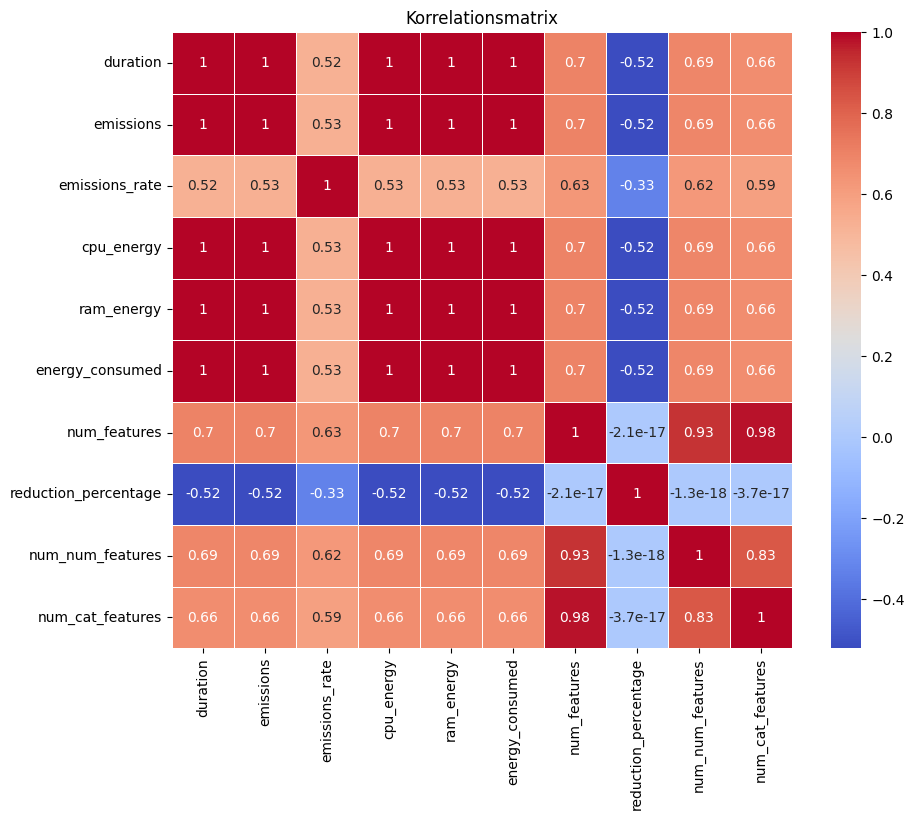

In [ ]:
visualize_correlation_matrix(decision_tree_df)

# Versuch 1 - Seperate Algorithmen


In [ ]:
# Funktion zum Model trainieren

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



def train_linreg_model(df):
  '''
  Für die seperaten Algorithmen kann der Modelname entfernt werden, da dieser
  keinen Einfluss haben wird
  '''
  X = df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
  y = df['energy_consumed']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  regressor = LinearRegression()
  regressor.fit(X_train, y_train)

  return regressor, X_train, X_test, y_train, y_test

In [ ]:
# Funktion zum Model trainieren

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



def train_rfreg_model(df):
  '''
  Für die seperaten Algorithmen kann der Modelname entfernt werden, da dieser
  keinen Einfluss haben wird
  '''
  X = df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
  y = df['energy_consumed']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  regressor = RandomForestRegressor()
  regressor.fit(X_train, y_train)

  return regressor, X_train, X_test, y_train, y_test

In [ ]:
# Funktion zum Model trainieren

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split



def train_dtreg_model(df):
  '''
  Für die seperaten Algorithmen kann der Modelname entfernt werden, da dieser
  keinen Einfluss haben wird
  '''
  X = df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
  y = df['energy_consumed']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  regressor = DecisionTreeRegressor()
  regressor.fit(X_train, y_train)

  return regressor, X_train, X_test, y_train, y_test

In [ ]:
# Funktion zum Model trainieren

import xgboost as xgb
from sklearn.model_selection import train_test_split


def train_xgbreg_model(df):
  '''
  Für die seperaten Algorithmen kann der Modelname entfernt werden, da dieser
  keinen Einfluss haben wird
  '''
  X = df[['num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features']]
  y = df['energy_consumed']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  regressor = xgb.XGBRegressor(objective="reg:squarederror")
  regressor.fit(X_train, y_train)

  return regressor, X_train, X_test, y_train, y_test

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


# Funktion zum Ergebnisse predicten
def get_predictions(regressor, X_test, X_train, y_test):
  predictions = regressor.predict(X_test)

  plt.scatter(y_test, predictions)
  regression_line = np.polyfit(y_test, predictions, 1)
  plt.plot(y_test, np.polyval(regression_line, y_test), color='red')
  plt.show()

  residuals = y_test - predictions
  plt.scatter(predictions, residuals)
  plt.axhline(y=0, color='red', linestyle='--')
  plt.xlabel("Vorhersagen")
  plt.ylabel("Residuen")
  plt.title("Residualplot")

  plt.show()

  r2 = r2_score(y_test, predictions)
  rmse = mean_squared_error(y_test, predictions, squared=False)
  mae = mean_absolute_error(y_test, predictions)
  mse = mean_squared_error(y_test, predictions)

  print(f'R2 Score: {r2}')
  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}')
  print(f'MSE: {mse}')

  return r2

## Random Forest

Lineare Regression (RandomForest Messdaten)

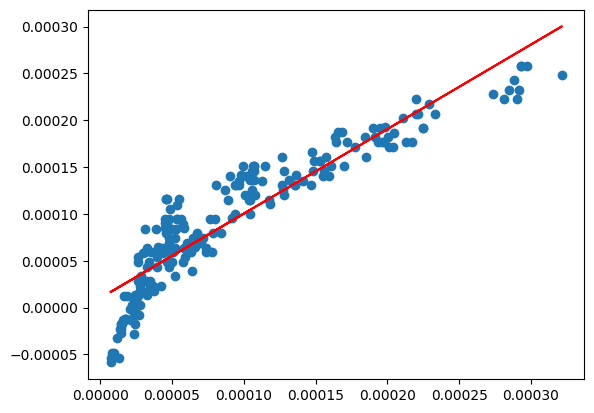

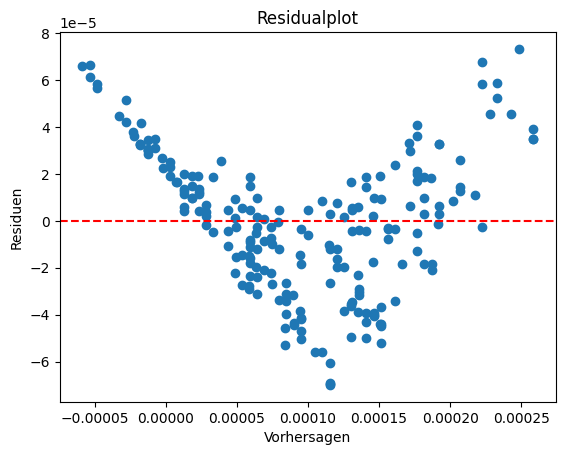

R2 Score: 0.8403351865592967
RMSE: 2.9795093926987013e-05
MAE: 2.4014270150875642e-05
MSE: 8.877476221179783e-10
0.8403351865592967


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(random_forest_df)
linreg_rf_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor  (RandomForest Messdaten)

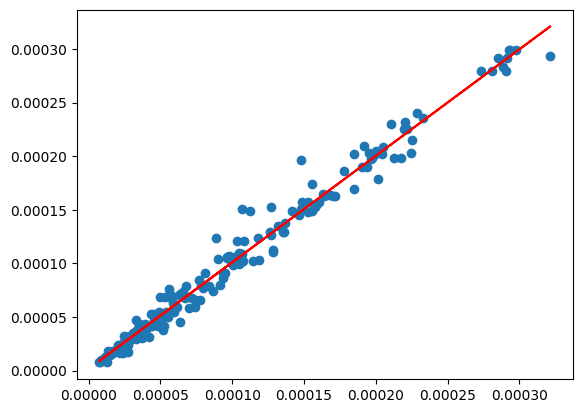

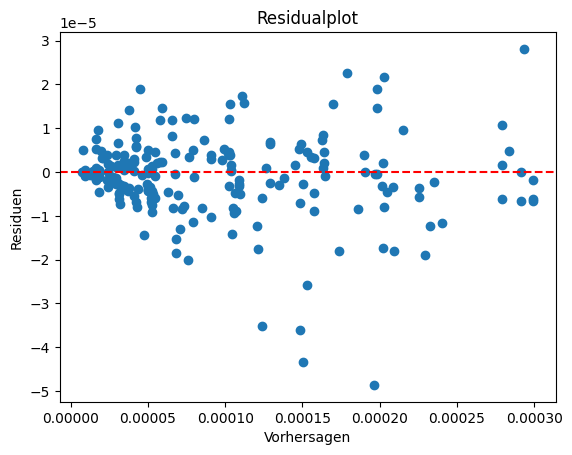

R2 Score: 0.9829083203502672
RMSE: 9.748381616403427e-06
MAE: 6.526176358394575e-06
MSE: 9.50309441390323e-11


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(random_forest_df)
rfreg_rf_r2 = get_predictions(regressor, X_test, X_train, y_test)

DecisionTree Regressor  (RandomForest Messdaten)

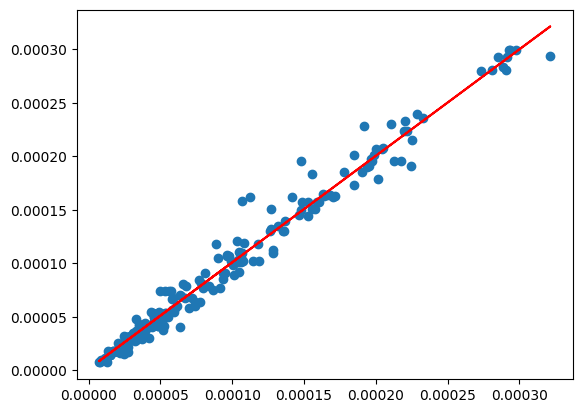

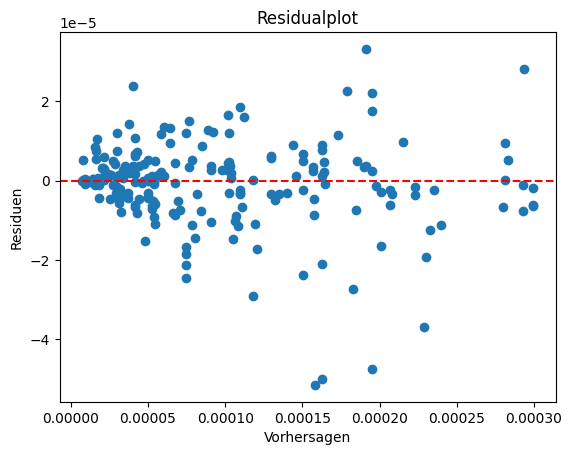

R2 Score: 0.9780000085643894
RMSE: 1.1059905234552482e-05
MAE: 7.230232350028411e-06
MSE: 1.2232150379728139e-10


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(random_forest_df)
dtreg_rf_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (RandomForest Messdaten)

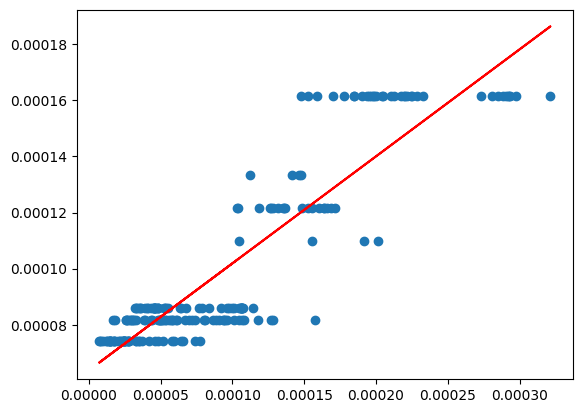

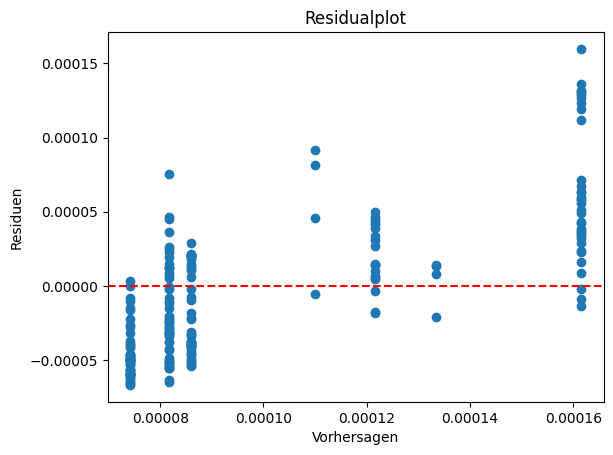

R2 Score: 0.5792020834166581
RMSE: 4.837009500105729e-05
MAE: 3.9759360572284294e-05
MSE: 2.339666090411308e-09


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(random_forest_df)
xgbreg_rf_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset randomforest')
print(f'linreg: {linreg_rf_r2}')
print(f'rfreg:  {rfreg_rf_r2}')
print(f'dtreg:  {dtreg_rf_r2}')
print(f'xgbreg: {xgbreg_rf_r2}')

R2 Scores for dataset randomforest
linreg: 0.8403351865592967
rfreg:  0.9829083203502672
dtreg:  0.9780000085643894
xgbreg: 0.5792020834166581


## XGB

Lineare Regression (XGB Messdaten)

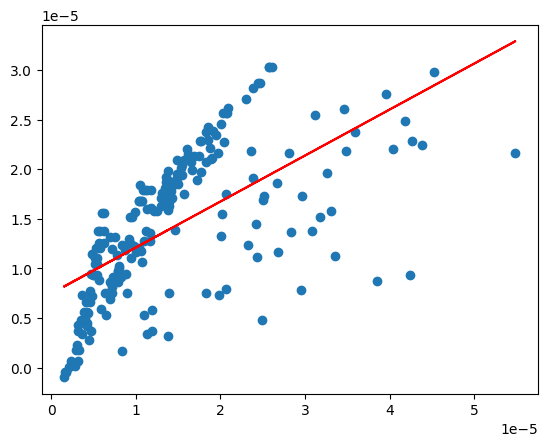

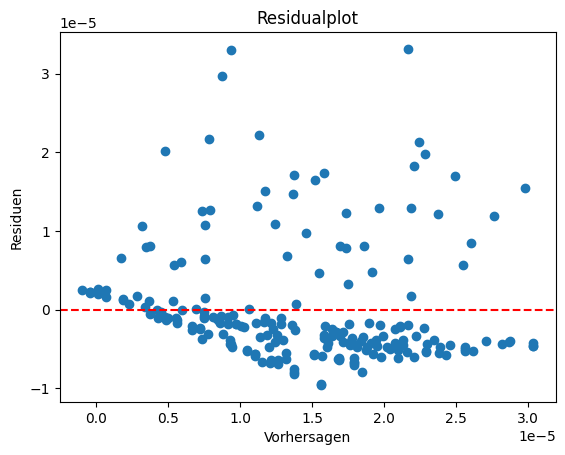

R2 Score: 0.3995987663783874
RMSE: 7.79106264920726e-06
MAE: 5.594075248755166e-06
MSE: 6.070065720387246e-11


In [ ]:
#train_model(xgb_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(xgb_df)
linreg_xgb_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor (XGB Messdaten)

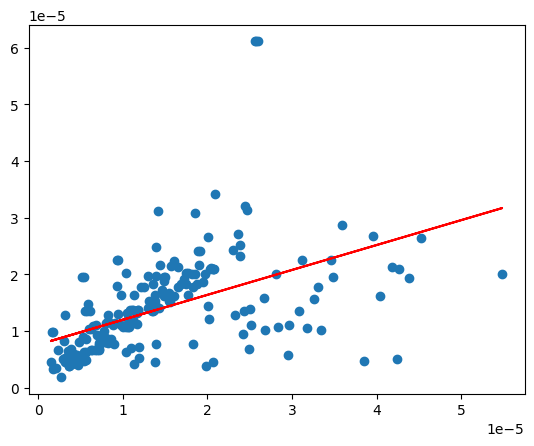

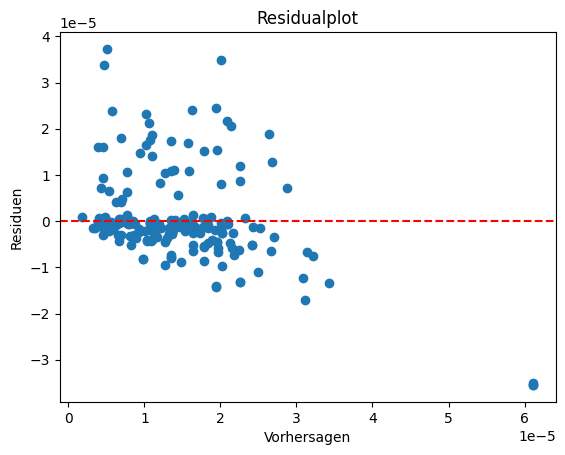

R2 Score: 0.08866365527135134
RMSE: 9.598762671963493e-06
MAE: 5.750172027163402e-06
MSE: 9.213624483267973e-11


In [ ]:
#train_model(xgb_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(xgb_df)
rfreg_xgb_r2 = get_predictions(regressor, X_test, X_train, y_test)

DecisionTree Regressor (XGB Messdaten)

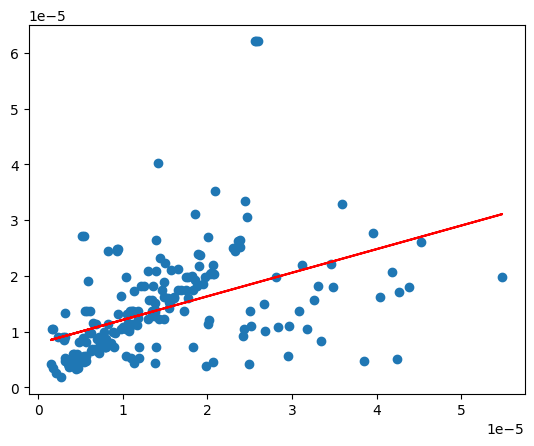

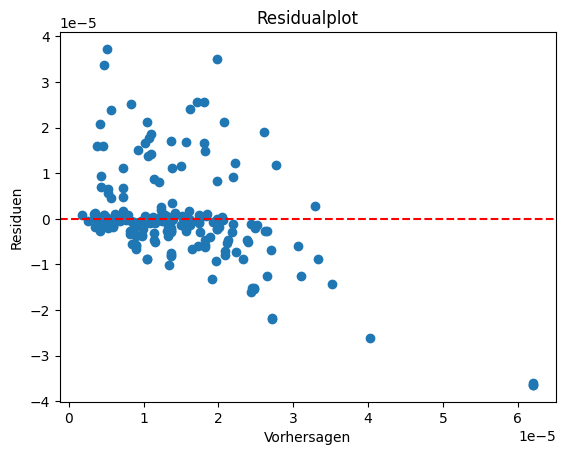

R2 Score: -0.03125104756332986
RMSE: 1.0210760978531981e-05
MAE: 6.075746803469336e-06
MSE: 1.0425963976071139e-10


In [ ]:
#train_model(xgb_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(xgb_df)
dtreg_xgb_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (XGB Messdaten)

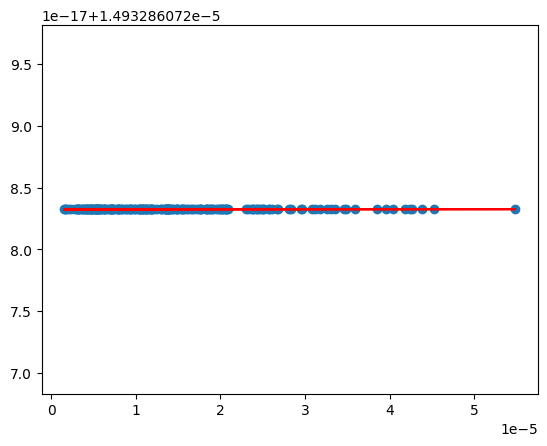

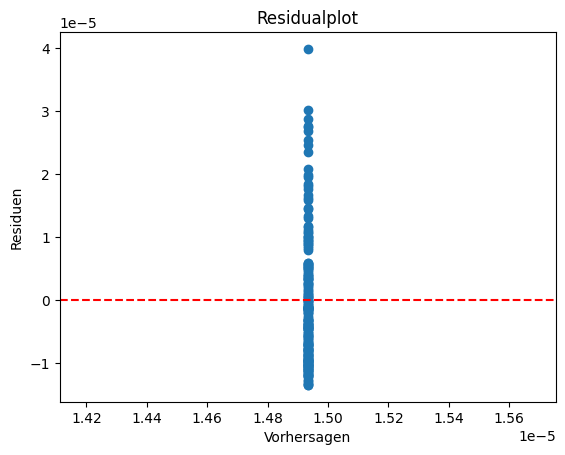

R2 Score: -0.003497201715772391
RMSE: 1.0072423823011559e-05
MAE: 7.912317216681245e-06
MSE: 1.0145372167037079e-10


In [ ]:
#train_model(xgb_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(xgb_df)
xgbreg_xgb_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset xgb')
print(f'linreg: {linreg_xgb_r2}')
print(f'rfreg:  {rfreg_xgb_r2}')
print(f'dtreg:  {dtreg_xgb_r2}')
print(f'xgbreg: {xgbreg_xgb_r2}')

R2 Scores for dataset xgb
linreg: 0.3995987663783874
rfreg:  0.08866365527135134
dtreg:  -0.03125104756332986
xgbreg: -0.003497201715772391


## Logistic Regression

Lineare Regression (LogisticRegression Messdaten)

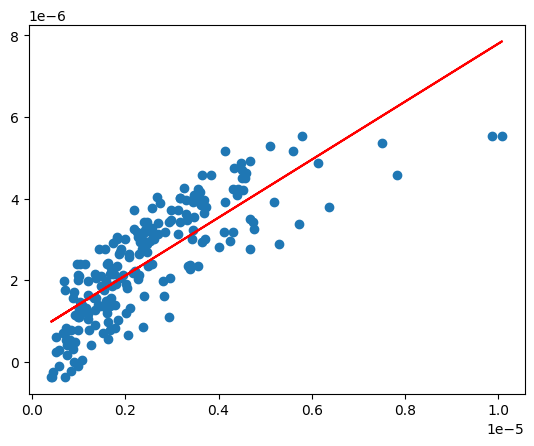

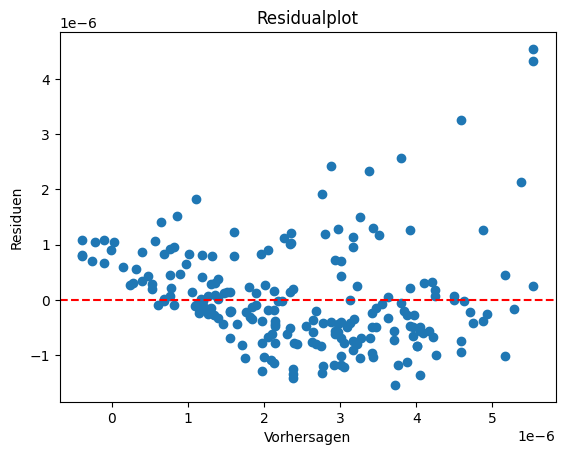

R2 Score: 0.6580409870903242
RMSE: 9.275613551957248e-07
MAE: 6.80133987272434e-07
MSE: 8.603700676525295e-13


In [ ]:
#train_model(logistic_regression_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(logistic_regression_df)
linreg_logreg_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor (LogisticRegression Messdaten)

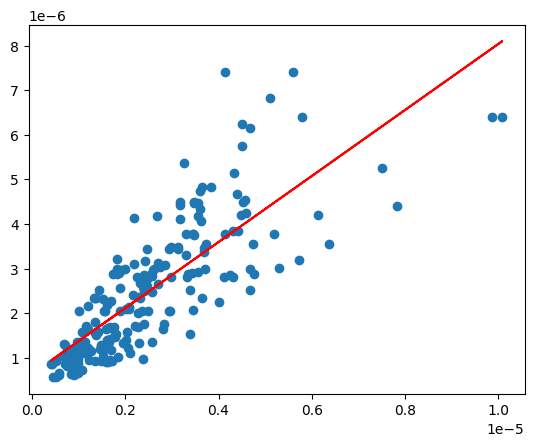

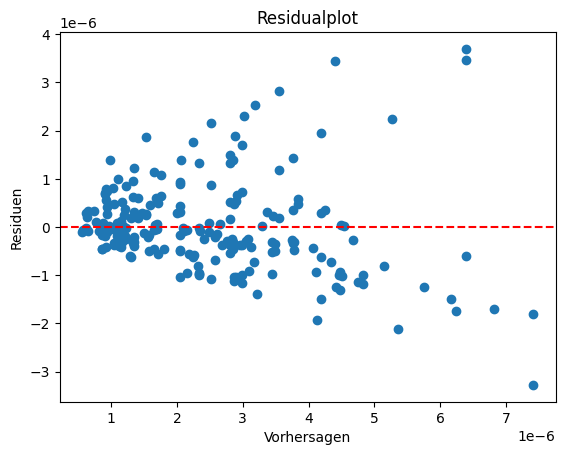

R2 Score: 0.6377888081571135
RMSE: 9.546332386809292e-07
MAE: 6.7597192298086e-07
MSE: 9.113246203944397e-13


In [ ]:
#train_model(logistic_regression_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(logistic_regression_df)
rfreg_logreg_r2 = get_predictions(regressor, X_test, X_train, y_test)

DecisionTree Regressor (LogisticRegression Messdaten)

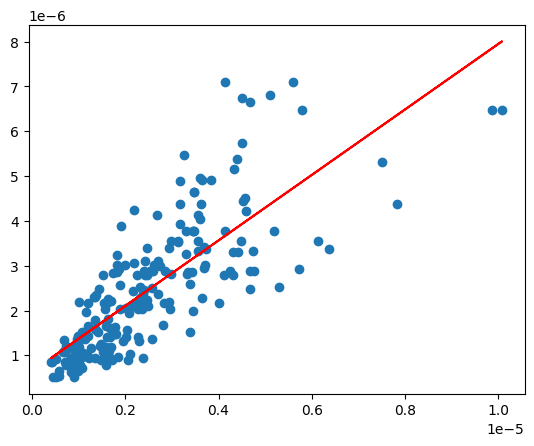

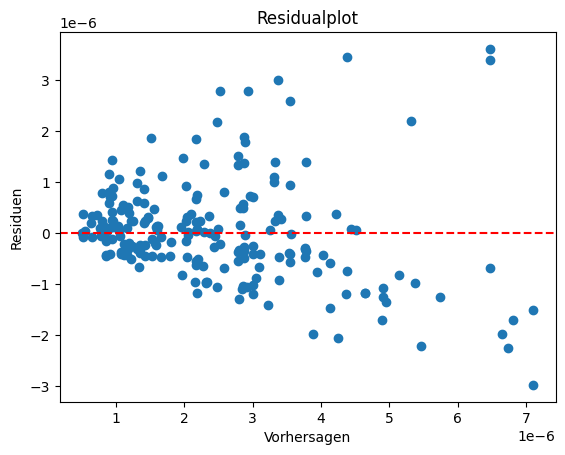

R2 Score: 0.6005484272328366
RMSE: 1.0025076301565817e-06
MAE: 7.120575404848415e-07
MSE: 1.0050215485221659e-12


In [ ]:
#train_model(logistic_regression_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(logistic_regression_df)
dtreg_logreg_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (LogisticRegression Messdaten)

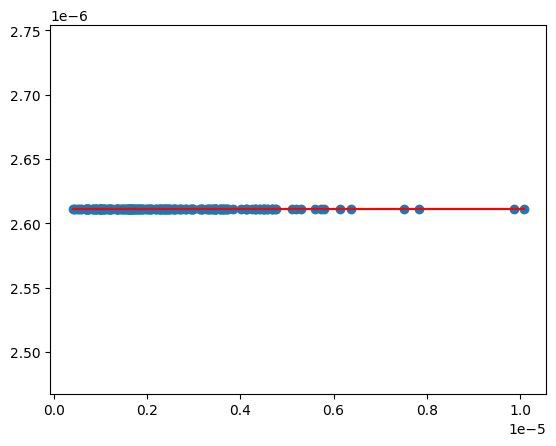

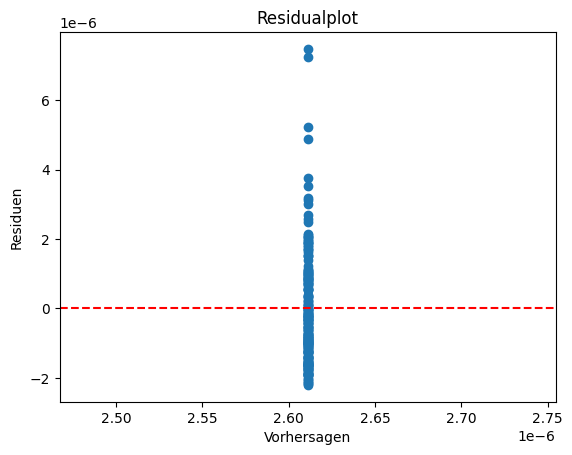

R2 Score: -0.005358995596045135
RMSE: 1.5904360203928192e-06
MAE: 1.2357584881526365e-06
MSE: 2.529486734962948e-12


In [ ]:
#train_model(logistic_regression_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(logistic_regression_df)
xgbreg_logreg_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset logistic regression')
print(f'linreg: {linreg_logreg_r2}')
print(f'rfreg:  {rfreg_logreg_r2}')
print(f'dtreg:  {dtreg_logreg_r2}')
print(f'xgbreg: {xgbreg_logreg_r2}')

R2 Scores for dataset logistic regression
linreg: 0.6580409870903242
rfreg:  0.6377888081571135
dtreg:  0.6005484272328366
xgbreg: -0.005358995596045135


## KNN

Lineare Regression (KNN Messdaten)

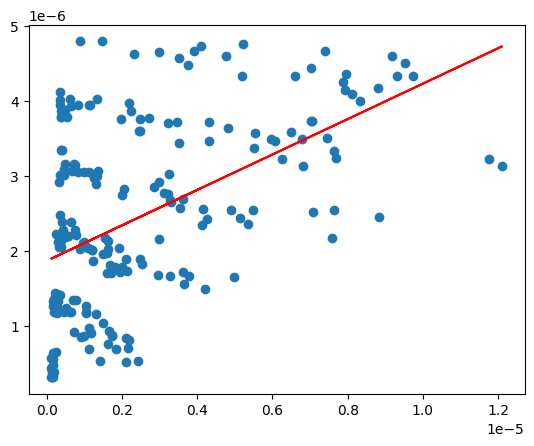

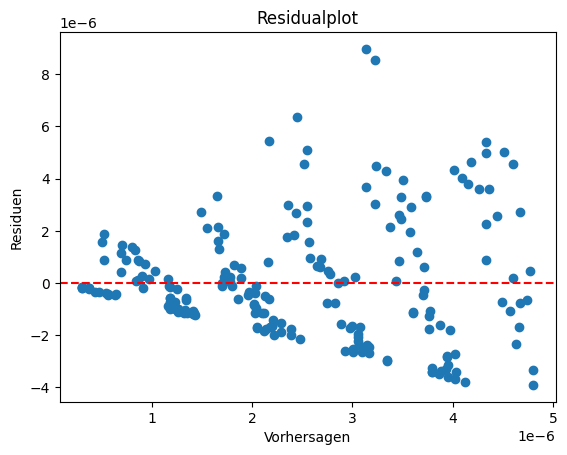

R2 Score: 0.24807574830352774
RMSE: 2.297031321281542e-06
MAE: 1.736562457201187e-06
MSE: 5.276352890948427e-12


In [ ]:
#train_model(knn_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(knn_df)
linreg_knn_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor (KNN Messdaten)

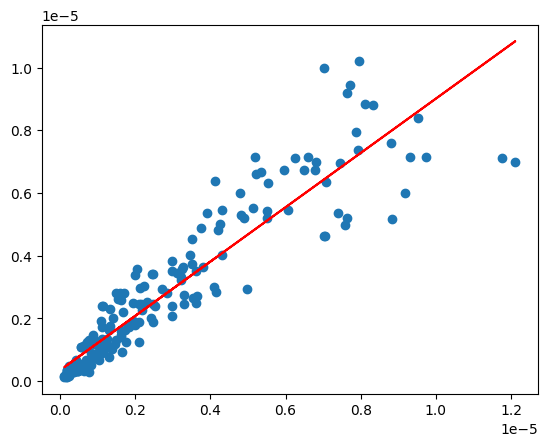

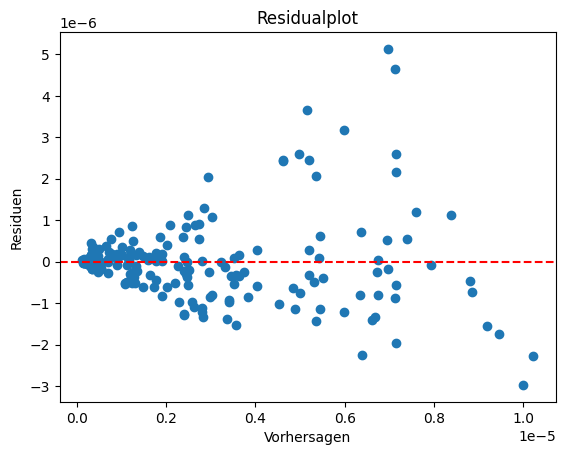

R2 Score: 0.8633420525412939
RMSE: 9.792584273305065e-07
MAE: 5.801162762437652e-07
MSE: 9.589470674978168e-13


In [ ]:
#train_model(knn_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(knn_df)
rfreg_knn_r2 = get_predictions(regressor, X_test, X_train, y_test)

DecisionTree Regressor (KNN Messdaten)

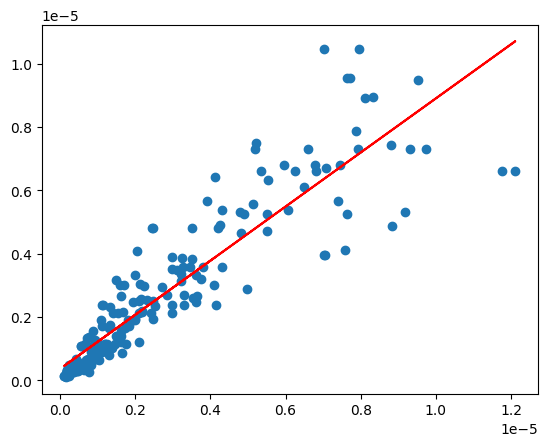

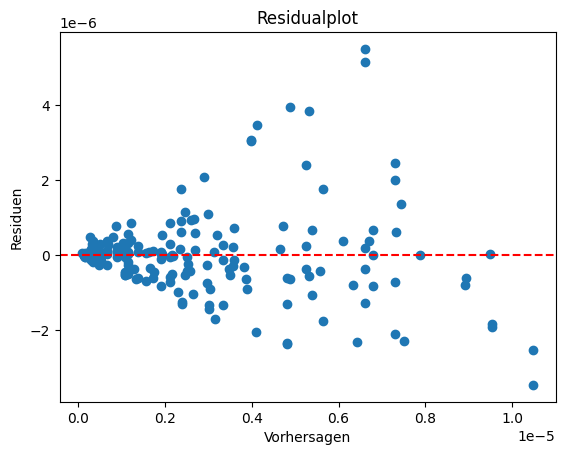

R2 Score: 0.8296225731790198
RMSE: 1.0934171927031113e-06
MAE: 6.259837515846657e-07
MSE: 1.1955611572987528e-12


In [ ]:
#train_model(knn_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(knn_df)
dtreg_knn_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (KNN Messdaten)

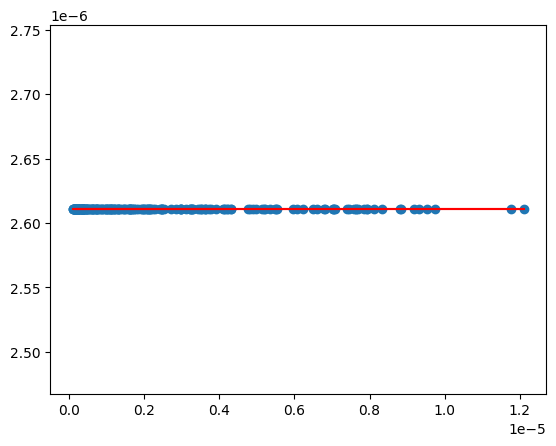

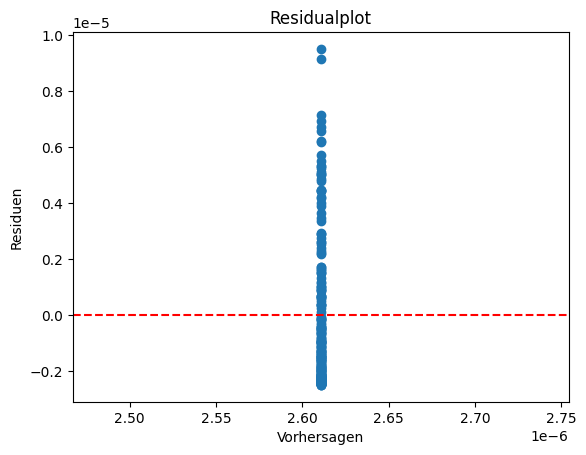

R2 Score: -0.0008562737132384868
RMSE: 2.6501211544797757e-06
MAE: 2.1289355418115106e-06
MSE: 7.0231421334212196e-12


In [ ]:
#train_model(knn_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(knn_df)
xgbreg_knn_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset KNN')
print(f'linreg: {linreg_knn_r2}')
print(f'rfreg:  {rfreg_knn_r2}')
print(f'dtreg:  {dtreg_knn_r2}')
print(f'xgbreg: {xgbreg_knn_r2}')

R2 Scores for dataset KNN
linreg: 0.24807574830352774
rfreg:  0.8633420525412939
dtreg:  0.8296225731790198
xgbreg: -0.0008562737132384868


## Gaussian

Lineare Regression (Gaussian Messdaten)

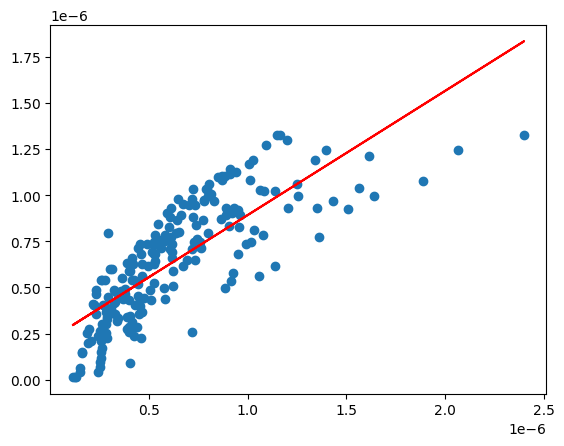

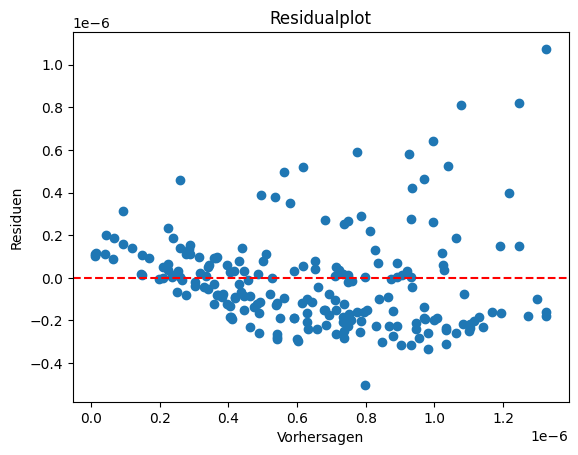

R2 Score: 0.6321983852139967
RMSE: 2.2757835756932425e-07
MAE: 1.698966576500054e-07
MSE: 5.17919088339512e-14


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(gaussian_nb_df)
linreg_gauss_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor (Gaussian Messdaten)

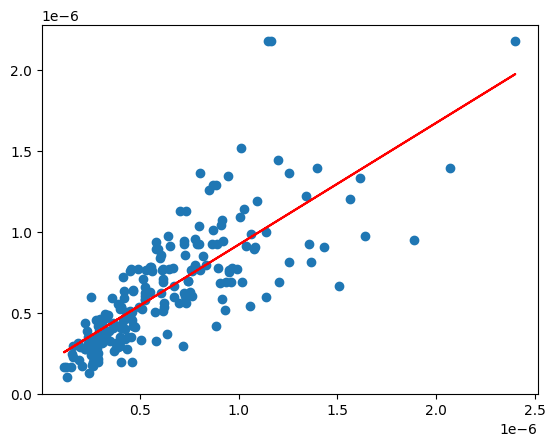

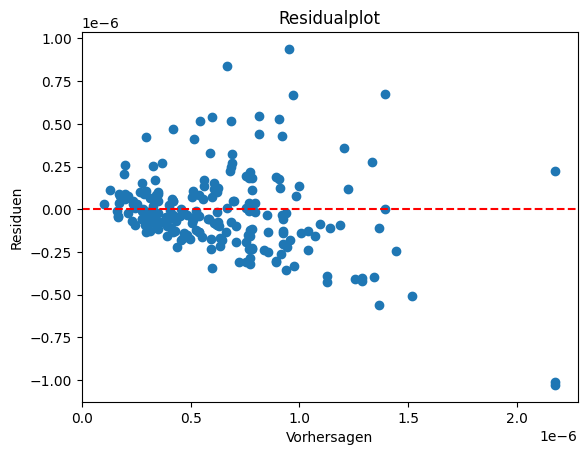

R2 Score: 0.5747297436193247
RMSE: 2.447127781607597e-07
MAE: 1.7013992647677368e-07
MSE: 5.988434379515719e-14


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(gaussian_nb_df)
rfreg_gauss_r2 = get_predictions(regressor, X_test, X_train, y_test)

DecisionTree Regressor (Gaussian Messdaten)

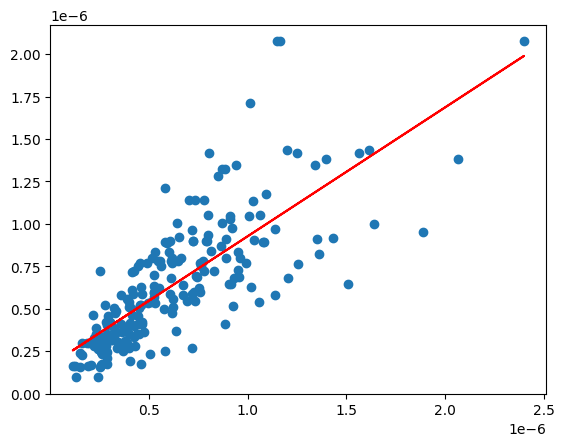

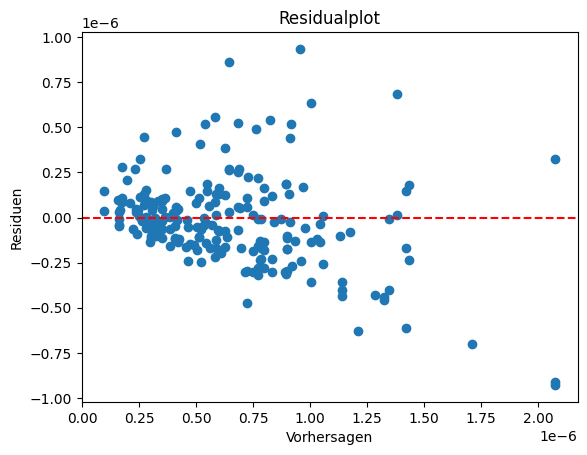

R2 Score: 0.5432608139562869
RMSE: 2.53605273331319e-07
MAE: 1.7815935218849268e-07
MSE: 6.431563466145303e-14


In [ ]:
#train_model(random_forest_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(gaussian_nb_df)
dtreg_gauss_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (Gaussian Messdaten)

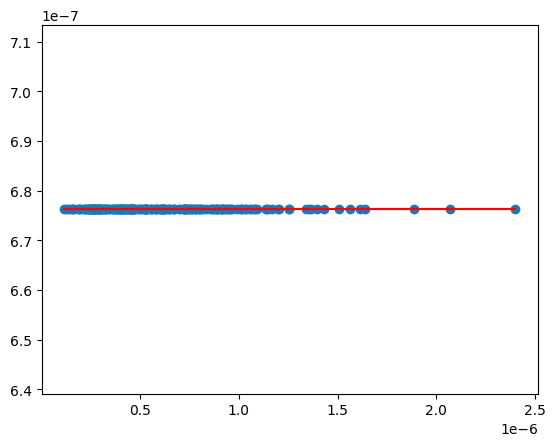

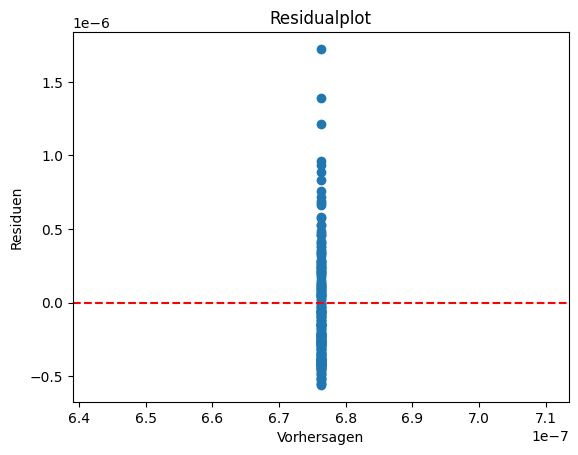

R2 Score: -0.018181917509646484
RMSE: 3.7864901632489224e-07
MAE: 3.01735630920438e-07
MSE: 1.4337507756380852e-13


In [ ]:
#train_model(gaussian_nb_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(gaussian_nb_df)
xgbreg_gauss_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset gaussian')
print(f'linreg: {linreg_gauss_r2}')
print(f'rfreg:  {rfreg_gauss_r2}')
print(f'dtreg:  {dtreg_gauss_r2}')
print(f'xgbreg: {xgbreg_gauss_r2}')

R2 Scores for dataset gaussian
linreg: 0.6321983852139967
rfreg:  0.5747297436193247
dtreg:  0.5432608139562869
xgbreg: -0.018181917509646484


## Decision Tree

Lineare Regression (DecisionTree Messdaten)

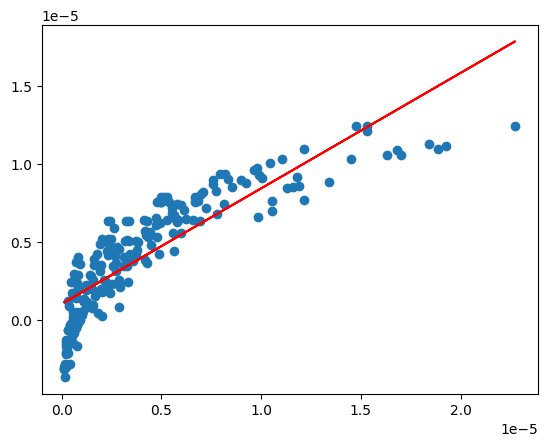

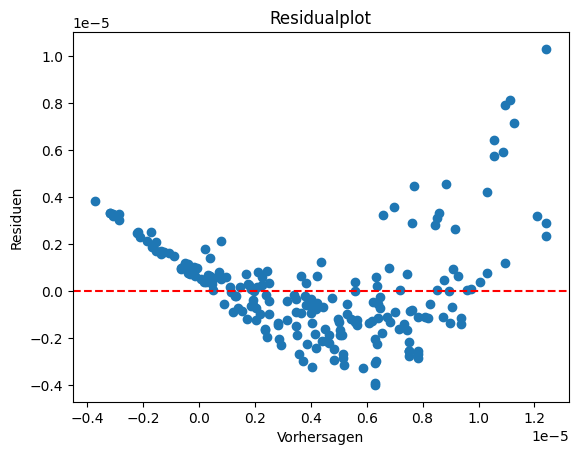

R2 Score: 0.7403412771859994
RMSE: 2.2194910230152036e-06
MAE: 1.6271586440111581e-06
MSE: 4.926140401245075e-12


In [ ]:
#train_model(decision_tree_df)
regressor, X_train, X_test, y_train, y_test = train_linreg_model(decision_tree_df)
linreg_dt_r2 = get_predictions(regressor, X_test, X_train, y_test)

RandomForest Regressor (DecisionTree Messdaten)

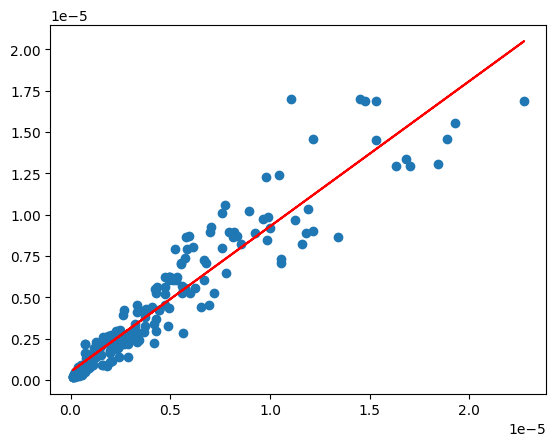

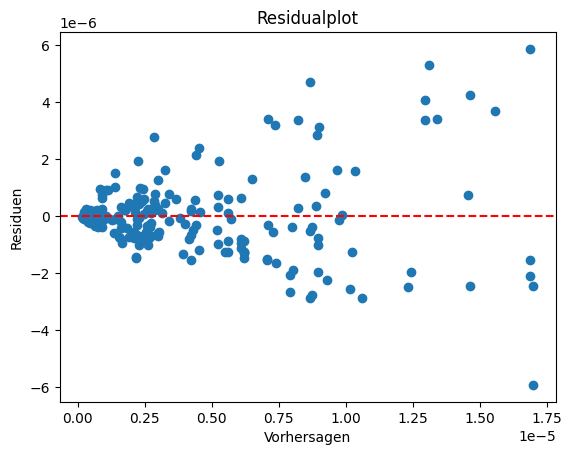

R2 Score: 0.8915845723632964
RMSE: 1.434159579403714e-06
MAE: 9.161104986838968e-07
MSE: 2.056813699195438e-12


In [ ]:
#train_model(decision_tree_df)
regressor, X_train, X_test, y_train, y_test = train_rfreg_model(decision_tree_df)
rfreg_dt_r2 = get_predictions(regressor, X_test, X_train, y_test)

DesicionTree Regressor (DecisionTree Messdaten)

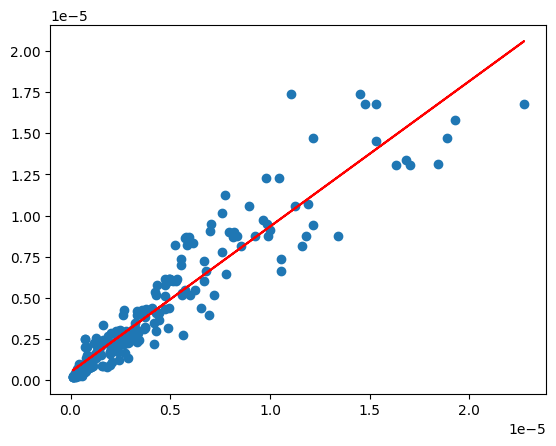

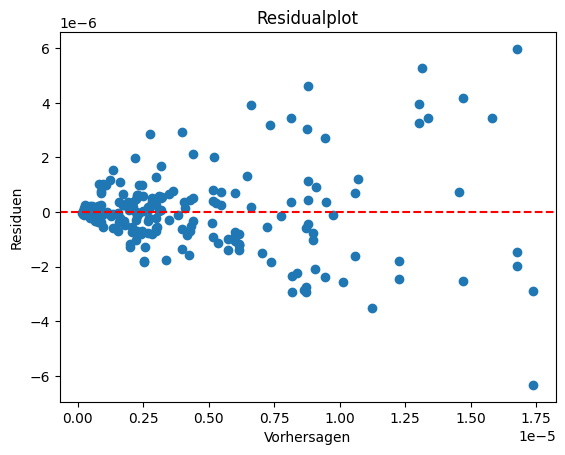

R2 Score: 0.8835869055381054
RMSE: 1.4861164838535183e-06
MAE: 9.522931645934224e-07
MSE: 2.2085422035811442e-12


In [ ]:
#train_model(decision_tree_df)
regressor, X_train, X_test, y_train, y_test = train_dtreg_model(decision_tree_df)
dtreg_dt_r2 = get_predictions(regressor, X_test, X_train, y_test)

XGB Regressor (DecisionTree Messdaten)

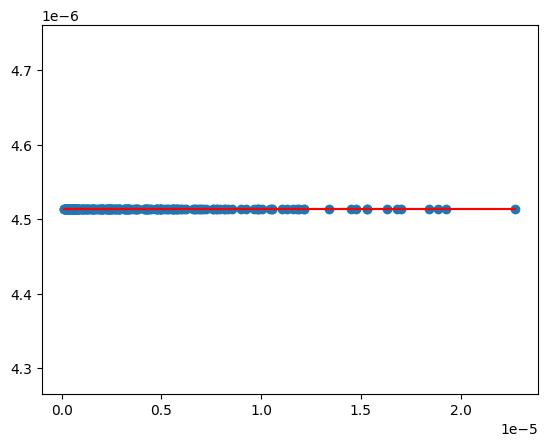

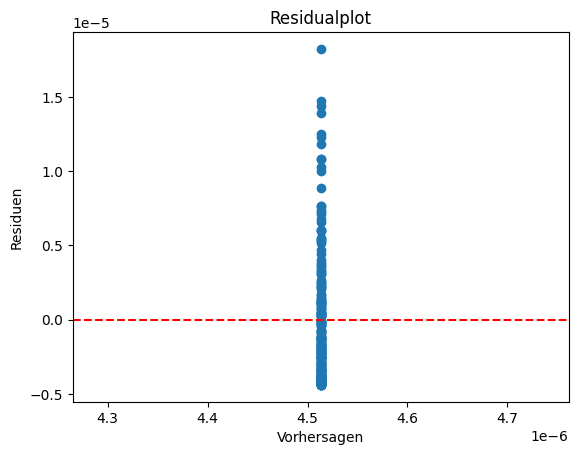

R2 Score: -0.002930155408276347
RMSE: 4.362016251602683e-06
MAE: 3.3397991595662976e-06
MSE: 1.9027185779245924e-11


In [ ]:
#train_model(decision_tree_df)
regressor, X_train, X_test, y_train, y_test = train_xgbreg_model(decision_tree_df)
xgbreg_dt_r2 = get_predictions(regressor, X_test, X_train, y_test)

In [ ]:
print('R2 Scores for dataset decisiontree')
print(f'linreg: {linreg_dt_r2}')
print(f'rfreg:  {rfreg_dt_r2}')
print(f'dtreg:  {dtreg_dt_r2}')
print(f'xgbreg: {xgbreg_dt_r2}')

R2 Scores for dataset decisiontree
linreg: 0.7403412771859994
rfreg:  0.8915845723632964
dtreg:  0.8835869055381054
xgbreg: -0.002930155408276347


### Oveview of all R2 values

In [ ]:
print('R2 Scores for dataset randomforest')
print(f'linreg: {linreg_rf_r2}')
print(f'rfreg:  {rfreg_rf_r2}')
print(f'dtreg:  {dtreg_rf_r2}')
print(f'xgbreg: {xgbreg_rf_r2}')
print()

print('R2 Scores for dataset xgb')
print(f'linreg: {linreg_xgb_r2}')
print(f'rfreg:  {rfreg_xgb_r2}')
print(f'dtreg:  {dtreg_xgb_r2}')
print(f'xgbreg: {xgbreg_xgb_r2}')
print()

print('R2 Scores for dataset logistic regression')
print(f'linreg: {linreg_logreg_r2}')
print(f'rfreg:  {rfreg_logreg_r2}')
print(f'dtreg:  {dtreg_logreg_r2}')
print(f'xgbreg: {xgbreg_logreg_r2}')
print()

print('R2 Scores for dataset KNN')
print(f'linreg: {linreg_knn_r2}')
print(f'rfreg:  {rfreg_knn_r2}')
print(f'dtreg:  {dtreg_knn_r2}')
print(f'xgbreg: {xgbreg_knn_r2}')
print()

print('R2 Scores for dataset gaussian')
print(f'linreg: {linreg_gauss_r2}')
print(f'rfreg:  {rfreg_gauss_r2}')
print(f'dtreg:  {dtreg_gauss_r2}')
print(f'xgbreg: {xgbreg_gauss_r2}')
print()

print('R2 Scores for dataset decisiontree')
print(f'linreg: {linreg_dt_r2}')
print(f'rfreg:  {rfreg_dt_r2}')
print(f'dtreg:  {dtreg_dt_r2}')
print(f'xgbreg: {xgbreg_dt_r2}')

R2 Scores for dataset randomforest
linreg: 0.8403351865592967
rfreg:  0.9829083203502672
dtreg:  0.9780000085643894
xgbreg: 0.5792020834166581

R2 Scores for dataset xgb
linreg: 0.3995987663783874
rfreg:  0.08866365527135134
dtreg:  -0.03125104756332986
xgbreg: -0.003497201715772391

R2 Scores for dataset logistic regression
linreg: 0.6580409870903242
rfreg:  0.6377888081571135
dtreg:  0.6005484272328366
xgbreg: -0.005358995596045135

R2 Scores for dataset KNN
linreg: 0.24807574830352774
rfreg:  0.8633420525412939
dtreg:  0.8296225731790198
xgbreg: -0.0008562737132384868

R2 Scores for dataset gaussian
linreg: 0.6321983852139967
rfreg:  0.5747297436193247
dtreg:  0.5432608139562869
xgbreg: -0.018181917509646484

R2 Scores for dataset decisiontree
linreg: 0.7403412771859994
rfreg:  0.8915845723632964
dtreg:  0.8835869055381054
xgbreg: -0.002930155408276347


# Versuch 2 - Alle Algorithmen